In [1]:
!pip install -q huggingface_hub datasets torch tqdm

In [2]:
import os
import sys
import torch
import json
import pickle
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, hf_hub_download

In [4]:
import os
!git clone https://github.com/bencejdanko/n-gram-modeling

# ensure latest
os.chdir('/content/n-gram-modeling')
!cd /content/n-gram-modeling && git pull

# copy over package
PACKAGE = "src"

import sys
sys.path.append(f"/content/n-gram-modeling/{PACKAGE}")

fatal: destination path 'n-gram-modeling' already exists and is not an empty directory.
Already up to date.


In [5]:
from data import get_jefferson_text, preprocess, build_vocab, TrigramDataset
from models import CountTrigramModel, NeuralTrigramModel
from train import train_neural_model
from decode import generate_greedy, generate_top_k, generate_nucleus, generate_beam_search
from eval import calculate_perplexity_count, calculate_perplexity_neural

In [16]:
import torch
import numpy as np
import random
import os

seed = 15179996

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [17]:
text = get_jefferson_text()
tokens = preprocess(text)

# Split into train and test
split_idx = int(len(tokens) * 0.9)
train_tokens = tokens[:split_idx]
test_tokens = tokens[split_idx:]

vocab, word2idx, idx2word = build_vocab(train_tokens)
vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")
print(f"Train tokens: {len(train_tokens)}")
print(f"Test tokens: {len(test_tokens)}")

Vocab size: 3005
Train tokens: 18574
Test tokens: 2064


# Count Model

In [18]:
train_idx = [word2idx[w] for w in train_tokens]
test_idx = [word2idx[w] for w in test_tokens if w in word2idx]

count_model = CountTrigramModel(vocab_size=vocab_size, add_k=0.1)
count_model.train(train_idx)

ppl_count = calculate_perplexity_count(count_model, test_idx)
print(f"Count Model Test Perplexity: {ppl_count:.4f}")

Count Model Test Perplexity: 1655.0892


## Neural Trigram Model

In [19]:
train_dataset = TrigramDataset(train_tokens, word2idx)
val_split = int(len(train_dataset) * 0.9)
train_ds, val_ds = torch.utils.data.random_split(train_dataset, [val_split, len(train_dataset) - val_split])
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
nn_model = NeuralTrigramModel(vocab_size=vocab_size, embed_size=64, hidden_size=128)
nn_model = train_neural_model(nn_model, train_loader, val_loader, epochs=50, patience=5, lr=1e-3, device=device)

test_dataset = TrigramDataset([w for w in test_tokens if w in word2idx], word2idx)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
ppl_nn = calculate_perplexity_neural(nn_model, test_loader, device=device)
print(f"Neural Model Test Perplexity: {ppl_nn:.4f}")

Epoch 1/50, Train Loss: 7.0367, Val Loss: 6.1870
Epoch 2/50, Train Loss: 5.6828, Val Loss: 5.9884
Epoch 3/50, Train Loss: 5.2788, Val Loss: 5.9405
Epoch 4/50, Train Loss: 4.9484, Val Loss: 5.9367
Epoch 5/50, Train Loss: 4.6145, Val Loss: 5.9683
Epoch 6/50, Train Loss: 4.2758, Val Loss: 6.0611
Epoch 7/50, Train Loss: 3.9279, Val Loss: 6.2084
Epoch 8/50, Train Loss: 3.5945, Val Loss: 6.4014
Epoch 9/50, Train Loss: 3.2918, Val Loss: 6.6102
Early stopping triggered at epoch 9
Neural Model Test Perplexity: 189.5495


k=0.001, Perplexity: 1237.86
k=0.010, Perplexity: 1213.06
k=0.100, Perplexity: 1655.09
k=0.500, Perplexity: 2161.24
k=1.000, Perplexity: 2385.00


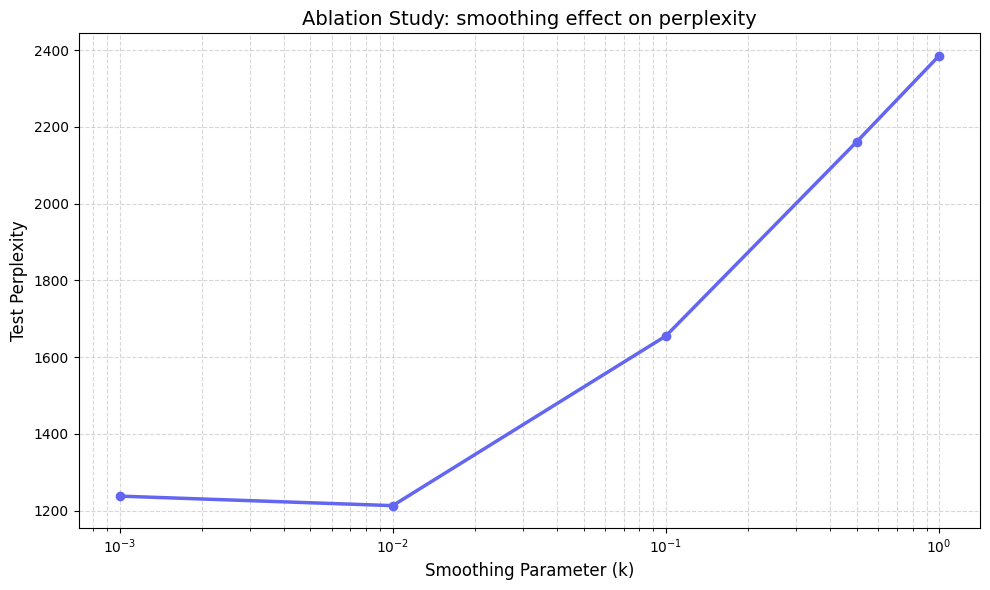

In [20]:
import numpy as np
import matplotlib.pyplot as plt

ks = [0.001, 0.01, 0.1, 0.5, 1.0]
perplexities = []

for k in ks:
    m = CountTrigramModel(vocab_size=vocab_size, add_k=k)
    m.train(train_idx)
    ppl = calculate_perplexity_count(m, test_idx)
    perplexities.append(ppl)
    print(f"k={k:.3f}, Perplexity: {ppl:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(ks, perplexities, marker='o', linestyle='-', color='#6366f1', linewidth=2.5)
plt.xscale('log')
plt.xlabel('Smoothing Parameter (k)', fontsize=12)
plt.ylabel('Test Perplexity', fontsize=12)
plt.title('Ablation Study: smoothing effect on perplexity', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [21]:
# Save Neural Model
torch.save(nn_model.state_dict(), 'nn_model.pth')

# Save Count Model (using pickle to preserve defaultdict structure)
with open('count_model.pkl', 'wb') as f:
    pickle.dump(count_model, f)

# Save Vocab
with open('vocab.json', 'w') as f:
    json.dump({'word2idx': word2idx, 'idx2word': {str(k): v for k, v in idx2word.items()}}, f)

print("Models and vocab saved locally.")

Models and vocab saved locally.


In [22]:
repo_id = "bdanko/n-gram-modeling"
api = HfApi()

files_to_upload = ["nn_model.pth", "count_model.pkl", "vocab.json"]

for filename in files_to_upload:
    try:
        api.upload_file(
            path_or_fileobj=filename,
            path_in_repo=filename,
            repo_id=repo_id
        )
        print(f"Uploaded {filename} to {repo_id}")
    except Exception as e:
        print(f"Failed to upload {filename}: {e}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  nn_model.pth                :  24%|##3       |  566kB / 2.39MB            

Uploaded nn_model.pth to bdanko/n-gram-modeling


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  count_model.pkl             : 100%|##########|  334kB /  334kB            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded count_model.pkl to bdanko/n-gram-modeling
Uploaded vocab.json to bdanko/n-gram-modeling


In [23]:
hf_nn_path = hf_hub_download(repo_id=repo_id, filename="nn_model.pth")
hf_count_path = hf_hub_download(repo_id=repo_id, filename="count_model.pkl")
hf_vocab_path = hf_hub_download(repo_id=repo_id, filename="vocab.json")

with open(hf_vocab_path, 'r') as f:
    hf_vocab_data = json.load(f)
    hf_word2idx = hf_vocab_data['word2idx']
    hf_idx2word = {int(k): v for k, v in hf_vocab_data['idx2word'].items()}

# Load Neural Model
loaded_nn_model = NeuralTrigramModel(vocab_size=len(hf_word2idx))
loaded_nn_model.load_state_dict(torch.load(hf_nn_path, weights_only=True))
loaded_nn_model.eval()

# Load Count Model
with open(hf_count_path, 'rb') as f:
    loaded_count_model = pickle.load(f)

print("Models loaded successfully from HF.")

nn_model.pth:   0%|          | 0.00/2.39M [00:00<?, ?B/s]

Models loaded successfully from HF.


In [24]:
w1_word, w2_word = "another", "year"
w1, w2 = hf_word2idx[w1_word], hf_word2idx[w2_word]
seed_text = f"{w1_word} {w2_word}"

# compute perplexity for text string
def get_text_perplexity(model, text, word2idx):
    # tokenize text
    tokens = text.split()
    indices = [word2idx[w] for w in tokens if w in word2idx]

    if hasattr(model, 'forward'):
        # neural model path
        from torch.utils.data import DataLoader
        from data import TrigramDataset
        ds = TrigramDataset(tokens, word2idx)
        loader = DataLoader(ds, batch_size=len(ds))
        return calculate_perplexity_neural(model, loader)
    else:
        # count model path
        return calculate_perplexity_count(model, indices)


w1_word, w2_word = "another", "year"
w1, w2 = hf_word2idx[w1_word], hf_word2idx[w2_word]
seed_text = f"{w1_word} {w2_word}"

strategies = [
    ("Greedy", generate_greedy, {}),
    ("Beam Search (w=3)", generate_beam_search, {"beam_width": 3}),
    ("Top-K (K=5)", generate_top_k, {"k": 5}),
    ("Nucleus (p=0.9)", generate_nucleus, {"p": 0.9})
]

models_to_test = [
    ("Count-based Trigram Model", loaded_count_model),
    ("Neural Trigram Model", loaded_nn_model)
]

for name, model in models_to_test:
    print(f"{name}")
    for strat_name, func, kwargs in strategies:
        generated = func(model, w1, w2, hf_word2idx, hf_idx2word, num_words=80, **kwargs)
        ppl = get_text_perplexity(model, generated, hf_word2idx)
        print(f"\n[{strat_name}] (Perplexity: {ppl:.2f})")
        print(generated)

Count-based Trigram Model

[Greedy] (Perplexity: 173.04)
another year has been also carried on by public armed ships to the united states a great consolation that it is our duty and our harbors and jurisdiction infringements on the 30th day of september last have amounted to near 15m which have been recently made into the mediterranean fund instead thereof an equal footing with that of the united states a great consolation that it is our duty and our harbors and jurisdiction infringements on the 30th day of september last

[Beam Search (w=3)] (Perplexity: 111.27)
another year will be laid before you by the secretary of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the united states a great portion of the